# 01-03 마켓과 머신러닝
`p.046`에서 시작



In [160]:
# 도미의 무게와 길이

bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

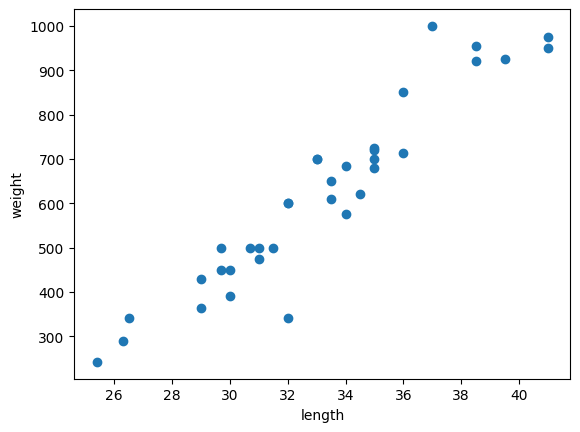

In [161]:
# 위의 두 데이터는 도미의 특성 (feature)입니다.

import matplotlib.pyplot as plt

# 산점도
plt.scatter(bream_length, bream_weight)
plt.xlabel("length")
plt.ylabel("weight")
plt.show()

# scatter(x, y)를 통해 (길이, 무게)에 대한 위치들을 나타내는 그림을 그립니다.

# 결과는 선형에 가까운 모습입니다.

In [162]:
# 빙어데이터도 함께 준비해보겠습니다.
# 빙어의 데이터 개수는 14개입니다.

smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

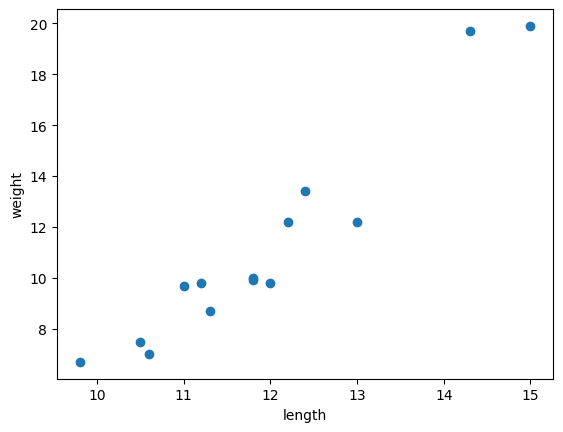

In [163]:
plt.scatter(smelt_length, smelt_weight)

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

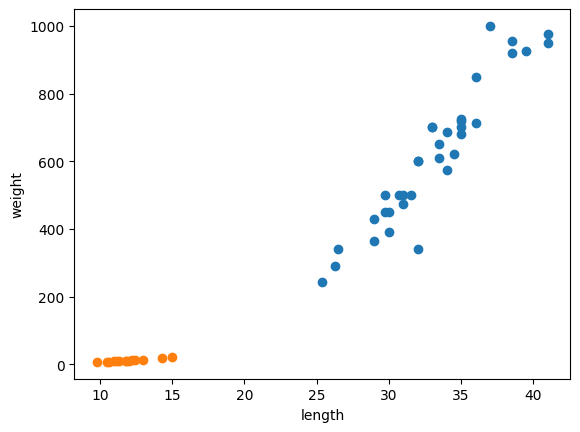

In [164]:
# 두 데이터를 함께 찍어보면 아래와 같은 결과가 나옵니다.

plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)

plt.xlabel("length")
plt.ylabel("weight")

plt.show()

위의 데이터를 보면 빙어는 도미에 비해 매우 가벼운 것으로 보입니다.
물론 길이 또한 매우 적은 것으로 보입니다.

축의 변화량을 보면 빙어의 길이 편차가 무게의 차이에 비해 매우 큰것을 확인할 수 있습니다.

In [165]:
# 최근접 이웃 알고리즘
# 두 데이터를 먼저 합쳐보겠습니다.
import pandas as pd

fish_length = bream_length + smelt_length
fish_weight = bream_weight + smelt_weight

fish_df = pd.DataFrame({
    "length": fish_length,
    "weight": fish_weight
})

fish_df.head()

,length,weight
0,25.4,242.0
1,26.3,290.0
2,26.5,340.0
3,29.0,363.0
4,29.0,430.0


머신러닝이 특정 [길이, 무게] 데이터를 보고 이것이 도미인지, 빙어인지를 구별하기 위해서는 규칙을 먼저 알려주어야합니다. 

따라서
- 도미: 1
- 빙어: 0

로 표현을 해보겠습니다.

In [166]:
fish_df["target"] = pd.Series([1]*len(bream_length) + [0]*len(smelt_length))
fish_df

,length,weight,target
0,25.4,242.0,1
1,26.3,290.0,1
2,26.5,340.0,1
3,29.0,363.0,1
4,29.0,430.0,1
5,29.7,450.0,1
6,29.7,500.0,1
7,30.0,390.0,1
8,30.0,450.0,1
9,30.7,500.0,1


# K-최근접 이웃 (K-Nearest Neighbors)

해당 알고리즘은 새 데이터가 들어오면 **기존 데이터중 가장 가까운 K개를 보고 판단하는** 알고리즘 입니다.

데이터가 N개 있을 경우에 학습(초기) 데이터가 주어집니다. 이후에 새로운 데이터가 들어올 때, 새로운 데이터의 위치에 따라 더 가까운 데이터를 발견할 시, 해당 데이터를 가까운 군집으로 분류한다는 의미입니다.

이때 `K`는 가까운 데이터를 보는 개수를 말합니다.

`K=3`이라면 가까운 데이터 3개를 보고 `군집A`가 더 많으면 `군집A`로 판단하게 됩니다.

이는 정답이 카테고리일 경우에는 **다수결로 결정하는 분류**로써 작용하며 정답이 숫자일 경우에는 **가까운 이웃들의 정답값의 평균을 내어 회귀**합니다.

> 기본적인 거리는 유클리드 거리공식을 사용합니다.

> **KNN**에서는 크기 범위나 편차, 간격에 따라 거리 공식에 큰 영향을 주므로 스케일링(정규화 또는 표준화)을 하게 됩니다.

> `K` 값이 너무 작거나 크지 않게 적절한 크기를 조절해주어야합니다.

### 장점
- 이해가 쉽다
- 분류/회귀 모두 가능하다
- 직관적이다
- 데이터가 적당히 작으면 잘 작동한다

### 단점
- 데이터가 많으면 예측이 느려진다
- 컬럼수가 너무 많으면 거리 개념이 약해진다
- 이상치에 영향이 크다
- 스케일링이 필수적이다
- 의미없는 특성이 많아질수록 결과가 왜곡되기 쉽다

> **KNN**은 학습할 때에는 그냥 저장해두는 것일 뿐이기 때문에 `fit()`에는 큰 비용이 들지 않지만 `predict()`를 할 경우에는 기존 학습 데이터들과 전부 거리를 계산해야 하기 때문에 데이터 수가 많아질수록 거리 연산을 `데이터 개수`*`예측 개수` 만큼 하게 됩니다.

> 메모리 또한 모든 데이터의 정보를 가지고 있어야 이후 연산에 사용할 수 있기 때문에 메모리 사용율 또한 높습니다.

In [167]:
from sklearn.neighbors import KNeighborsClassifier
# K-최근접 이웃 분류기

kn = KNeighborsClassifier()

kn.fit(fish_df[["length", "weight"]], fish_df["target"])
# 출력은 학습시킨 뒤 학습된 자신의 객체를 보여주는 것입니다.
# k값은 5
# 주위의 k개의 값들의 가중치를 같이함 (uniform)
# 알고리즘 자동선택
# metric: 거리 공식 선택 (유클리드)
# n_jobs: 병렬처리 안함

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [ ]:
kn.score(fish_df[["length", "weight"]], fish_df["target"])
# 1.0 = 100% 맞췄다는 뜻
# 정확도 = 100% 로 이해 가능
# fish_df의 행을 하나씩 진행하며 (length, weight)와 가까운 점 5개와 비교하여 3개 이상인 종류를 정답으로 삼음 (0 | 1)
# 이걸 49번 반복했을 때 다 맞췄다는 뜻. 일반적으로 과적합이지만일 가능성이 있습니다.

1.0

In [169]:
# 예시 데이터로 한번 실험해보기

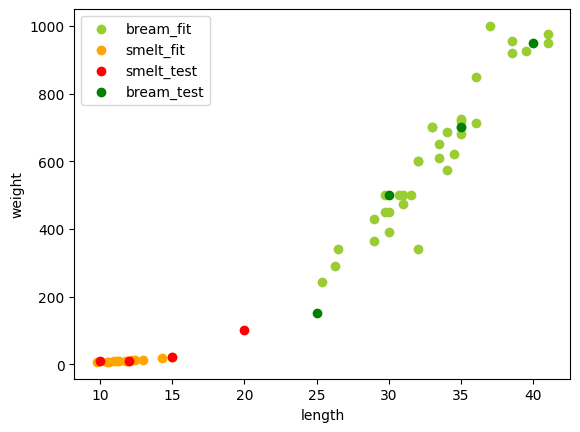

In [170]:
# 두 데이터를 함께 찍어보면 아래와 같은 결과가 나옵니다.

test_df = pd.DataFrame({
    "length": [30.0, 35.0, 10.0, 12.0, 20.0, 25.0, 15.0, 40.0],
    "weight": [500.0, 700.0, 8.0, 10.0, 100.0, 150.0, 20.0, 950.0],
    "target": [1, 1, 0, 0, 0, 1, 0, 1]
})


test_df

smelt = test_df["target"] == 0
bream = test_df["target"] == 1

plt.scatter(bream_length, bream_weight, color="yellowgreen", label="bream_fit")
plt.scatter(smelt_length, smelt_weight, color="orange", label="smelt_fit")
plt.scatter(test_df[smelt]["length"], test_df[smelt]["weight"], color="red", label="smelt_test")
plt.scatter(test_df[bream]["length"], test_df[bream]["weight"], color="green", label="bream_test")

plt.legend()
plt.xlabel("length")
plt.ylabel("weight")

plt.show()

In [171]:
print(f"예측: {kn.predict(test_df[["length", "weight"]]).tolist()}")
print(f"정답: {test_df["target"].tolist()}")

# 하나 빼고 맞추는 모습

예측: [1, 1, 0, 0, 0, 0, 0, 1]
정답: [1, 1, 0, 0, 0, 1, 0, 1]


In [172]:
# 참고 이웃 개수를 49로 설정
kn49 = KNeighborsClassifier(49)

kn49.fit(fish_df[["length", "weight"]], fish_df["target"])
# 예측: 49개의 데이터를 모두 참고하면 항상 데이터가 더 많은 **도미**가 결과로 나올 것이다.

# 학습 데이터 정확도: 약 71.43%
print(kn49.score(fish_df[["length", "weight"]], fish_df["target"]))

print(kn49.predict(test_df[["length", "weight"]]))
# 정답

0.7142857142857143
[1 1 1 1 1 1 1 1]


# KNN 정리
KNN은 기본적인 실험용 임시 소형 모델입니다.

연산 비용과 메모리 비용이 장난 아니므로 큰 데이터에 잘못 돌려서 피보지 말도록 해야합니다.

적용할 이웃 개수를 적용할 수 있으며 가까운 순위에 따라 크거나 작은 가중치를 줄 수 있으며 거리 공식 또한 바꿀 수 있습니다. 차원은 꼭 2개일 필요는 없지만 너무 많아질 수록 왜곡되기 쉽습니다.

> 중요한 모델은 아니니 일단 넘어가도 좋습니다.

# 훈련 세트워 테스트 세트
`p.066`부터 진행하는 **지도 학습**과 **비지도 학습**의 차이를 공부합니다.

머신러닝 알고리즘에서 훈련을 위한 데이터 셋에는 크게 **정답이 있는 데이터와 없는 데이터**로 나뉩니다.

당연하게도, 정답이 있는 데이터를 통한 학습을 **지도 학습**, 없는 데이터를 통한 학습을 **비지도 학습**이라고 부릅니다.

> 추가적으로 **강화 학습**이라는 어떤 주체의 행동에 따라 보상을 주며 전략을 수정하게 해주는 방법이 있습니다.

## 학습 과정
우선 모델을 학습하기 위한 데이터셋은 크게 3가지로 나뉩니다.
- 훈련용 데이터 셋
- 검증용 데이터 셋
- 테스트 데이터 셋

이를 통해 훈련용을 통해 훈련 -> 검증 후 테스트를 통해 결과를 만들게 됩니다.

이는 데이터가 오직 훈련용에 맞춰져 만들어지는 것을 방지하기 위해 훈련용 데이터 셋을 통한 모델 생성 후, 검증을 통해 이것이 훈련용에 과적합 되었는지 검토, 마지막으로 테스트 데이터 셋을 통해 모델의 신뢰도를 측정합니다.

> 위 3가지 데이터로 나누기 위해서는 `수집`, `정제`, `탐색(변환)`, `특성 공학`, `분할` 과 같은 작업이 사용됩니다.

## 학습 종류
검색해보니 아래와 같은 학습 종류가 있습니다. 아래 학습 종류들은 나중에 따로 다뤄보겠습니다.
### 지도 학습
정답이 있는 데이터를 사용하여 입력 특성과 정답 사이의 관계를 학습하거나 활용합니다.
- KNN
- 선형 회귀
- 로지스틱 회귀
- 의사결정 나무
### 비지도 학습
- K-평균
- 밀도 기반 군집화
- 차원축소
- 연관 규칙 학습
- 밀도 추정
### 강화학습
- 가치 기반 알고리즘 (Q-Learning, DQN)
- 정책 기반 알고리즘
- 액터-크리틱 알고리즘 (자주 쓰임)

In [173]:

fish_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0, 9.8, 
                10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
fish_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0, 6.7, 
                7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

In [174]:
fish_df= pd.DataFrame({
    "length": fish_length, 
    "weight": fish_weight,
    "target": ([1]*35 + [0]*14)
})
fish_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   length  49 non-null     float64
 1   weight  49 non-null     float64
 2   target  49 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 1.3 KB


In [175]:
kn = KNeighborsClassifier()

train_df = fish_df[:35]
test_df = fish_df[35:]

kn.fit(train_df[["length", "weight"]], train_df["target"])
print(kn.score(test_df[["length", "weight"]], test_df["target"]))
# 앞의 35개는 도미로만 지도 학습
# 뒤의 데이터는 모두 빙어이기 때문에 모델은 아예 빙어 존재 여부 자체를 몰라서 맞출 수가 없다. 뭘 해도 1로 취급하는 상황!

kn.predict(test_df[["length", "weight"]])

0.0


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

1.0


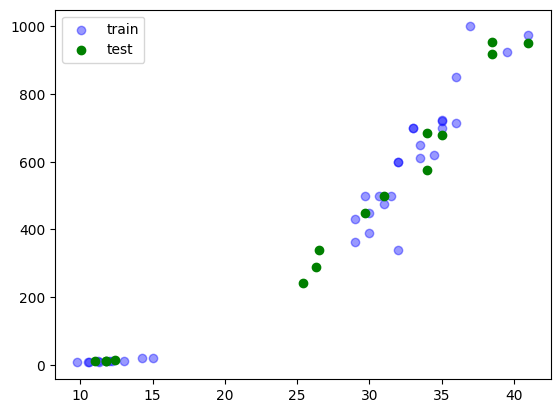

In [176]:
# 위의 오류를 고치기 위해 도미와 빙어의 데이터 셋을 고르게 바꿔주어야 합니다.
# 위의 상황을 편향이라고 부릅니다.
# pandas의 sample 기능을 사용해보겠습니다.

# fish_df.sample(frac=0.7) # 7할 뽑기
# fish_df.sample(n=35) # n개 뽑기
# fish_df.sample(n=35, random_state=42) # 시드 고정
# fish_df.sample(n=35, replace=True, random_state=42) # 복원 추출

# 다른 방법으로는 sklearn을 이용하는 방법이 있습니다.
from sklearn.model_selection import train_test_split

X = fish_df[["length", "weight"]]
y = fish_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y # 훈련/테스트의 결과(y) 비율을 같게 하는 옵션입니다.
)

kn.fit(X_train, y_train)
# 정확도 무려 100% (무작정 잘된거라 볼 수는 없지만 그래도 좋은 결과)
print(kn.score(X_test, y_test))
plt.scatter(X_train["length"], X_train["weight"], label="train", color="b", alpha=0.4)
plt.scatter(X_test["length"], X_test["weight"], label="test", color="g")

plt.legend()

# 보았을 때 고르게 잘 설정된 모습
plt.show()

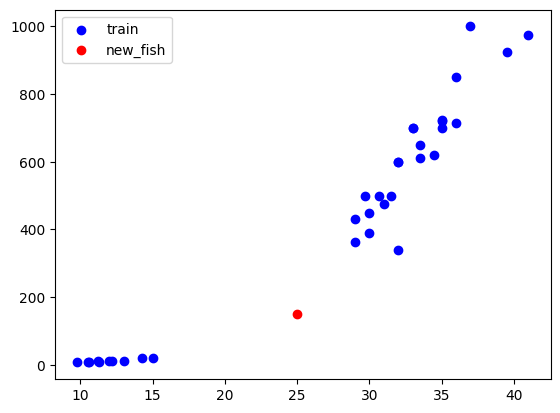

In [177]:
# 문제 상황
error_fish = [25, 150] # 이것은 무엇일까요

plt.scatter(X_train["length"], X_train["weight"], label="train", color="b", alpha=1)
# plt.scatter(X_test["length"], X_test["weight"], label="test", color="g")
plt.scatter(error_fish[0], error_fish[1], label="new_fish", color="r")

plt.legend()

# 보았을 때 고르게 잘 설정된 모습
plt.show()

In [178]:
import numpy as np
kn.predict([[25, 150]]) # 눈으로 보면 도미 쪽에 가까운데 결과는 빙어라고 나옵니다.

c:\HUR\Document\lang-chain-KDT\workspace\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([0])

# KNN의 문제 상황
위와 같이 눈으로 보기에는 B군집에 가까워 보여도 실제로 `x`는 얼마 차이나지 않고(범위나 단위 자체가) `y`는 단위가 `gram`이기 때문에 차이가 더 날 수 있습니다.

이 때문에 데이터를 **전처리** 해야 하며 이 중 많이 이용되는 방식은 **표준 점수**입니다.

In [ ]:
# 직접 계산 하기 위해선 아래와 같은 공식을 사용 가능합니다.
m = fish_df[["length", "weight"]].mean()
s = fish_df[["length", "weight"]].std()
fish_df[["length", "weight"]] = (fish_df[["length", "weight"]] - m) / s

# 더 편하게 하기 위해선 sklearn 사용
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# fish_df[["length", "weight"]] = pd.DataFrame(
#   scaler.fit_transform(fish_df[["length", "weight"]]),
#   columns=["length", "weight"]
# )

# 하는김에 예측용 데이터도
new_fish = (np.array([25, 150]) - m.to_numpy()) / s.to_numpy()
print(m.to_numpy())
print(np.array([25, 150]) - m.to_numpy())
print(new_fish)
print(fish_df.head())

[ 27.05510204 444.5       ]
[  -2.05510204 -294.5       ]
[-0.20063863 -0.89747394]
     length    weight  target
0 -0.161587 -0.617109       1
1 -0.073720 -0.470831       1
2 -0.054194 -0.318458       1
3  0.189879 -0.248367       1
4  0.189879 -0.044188       1


1.0


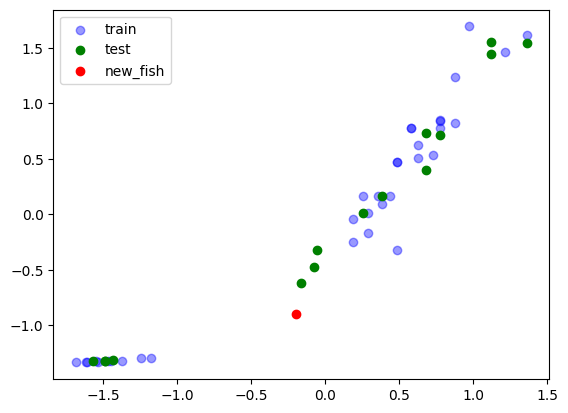

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    fish_df[["length", "weight"]], y,
    test_size=0.3,
    random_state=42,
    stratify=y # 훈련/테스트의 결과(y) 비율을 같게 하는 옵션입니다.
)

kn.fit(X_train, y_train)
# 정확도 무려 100% (무작정 잘된거라 볼 수는 없지만 그래도 좋은 결과)
print(kn.score(X_test, y_test))
plt.scatter(X_train["length"], X_train["weight"], label="train", color="b", alpha=0.4)
plt.scatter(X_test["length"], X_test["weight"], label="test", color="g")
plt.scatter(new_fish[0], new_fish[1], label="new_fish", color="r")


plt.legend()

# 보았을 때 고르게 잘 설정된 모습
plt.show()

In [ ]:
# 이후 다시 예측
# [25, 150] 표준화
print(new_fish)

kn.predict([new_fish]) # 도미로 예측되는 모습

[-0.20063863 -0.89747394]


c:\HUR\Document\lang-chain-KDT\workspace\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


array([1])